<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


In this lab, you will focus on the visualization of data. The dataset will be provided through an RDBMS, and you will need to use SQL queries to extract the required data.


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


### Setup: Connecting to the Database


#### 1. Download the Database File


In [1]:
!wget https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite

--2026-07-26 00:05:56--  https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/QR9YeprUYhOoLafzlLspAw/survey-results-public.sqlite
Resolving cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)... 169.63.118.104
Connecting to cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud (cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud)|169.63.118.104|:443... connected.
200 OKequest sent, awaiting response... 
Length: 211415040 (202M) [application/octet-stream]
Saving to: ‘survey-results-public.sqlite’

survey-results-publ 100%[===================>] 201.62M  40.3MB/s    in 4.8s    

2026-07-26 00:06:03 (41.9 MB/s) - ‘survey-results-public.sqlite’ saved [211415040/211415040]



#### 2. Connect to the Database


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 138.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 175.1 MB/s eta 0:00:00


In [3]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 154.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 162.8 MB/s eta 0:00:00


In [4]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connect to the SQLite database
conn = sqlite3.connect('survey-results-public.sqlite')


## Demo: Basic SQL Queries


#### Demo 1: Count the Number of Rows in the Table


In [5]:
QUERY = "SELECT COUNT(*) FROM main"
df = pd.read_sql_query(QUERY, conn)
print(df)


   COUNT(*)
0     65437


#### Demo 2: List All Tables


In [6]:
QUERY = """
SELECT name as Table_Name 
FROM sqlite_master 
WHERE type = 'table'
"""
pd.read_sql_query(QUERY, conn)


,Table_Name
0,main


#### Demo 3: Group Data by Age


In [7]:
QUERY = """
SELECT Age, COUNT(*) as count 
FROM main 
GROUP BY Age 
ORDER BY Age
"""
df_age = pd.read_sql_query(QUERY, conn)
print(df_age)


                  Age  count
0     18-24 years old  14098
1     25-34 years old  23911
2     35-44 years old  14942
3     45-54 years old   6249
4     55-64 years old   2575
5   65 years or older    772
6   Prefer not to say    322
7  Under 18 years old   2568


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


/tmp/ipykernel_300/2705081756.py:25: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_check['CompTotal'].dropna(), vert=False)


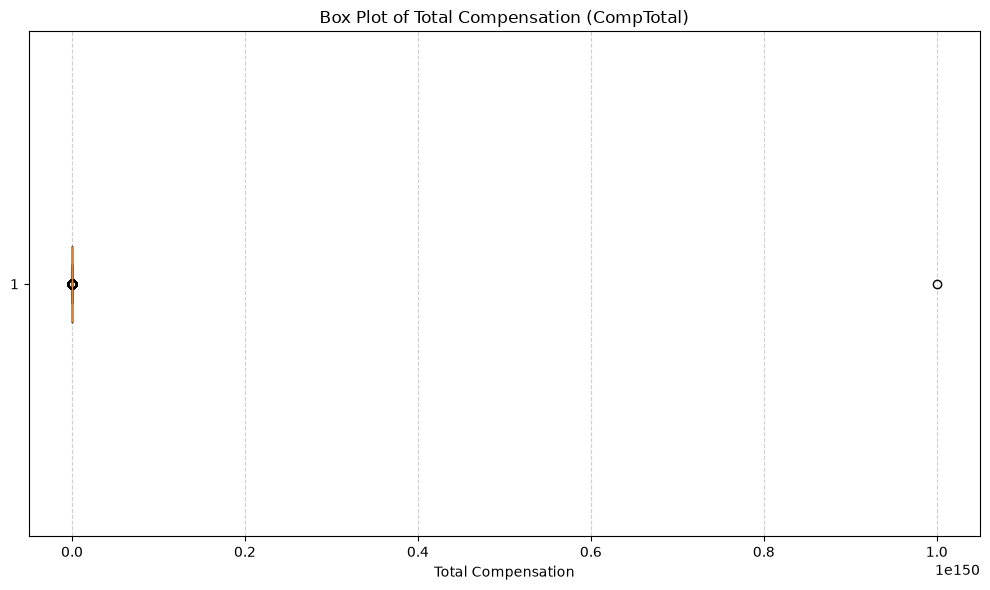

In [15]:
# your code goes here
#df_check['CompTotal'].nlargest(10)
# df_clean = df_check[df_check['CompTotal'] < 1_000_000]
# df_clean
# import matplotlib.pyplot as plt

# plt.figure(figsize=(10,6))
# plt.boxplot(df_clean['CompTotal'].dropna(), vert=False)

# plt.title("Box Plot of Total Compensation (Cleaned)")
# plt.xlabel("Total Compensation")
# plt.grid(axis='x', linestyle='--', alpha=0.6)
# plt.tight_layout()
# plt.show()
df_check['CompTotal'] = (
    df_check['CompTotal']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.boxplot(df_check['CompTotal'].dropna(), vert=False)

plt.title("Box Plot of Total Compensation (CompTotal)")
plt.xlabel("Total Compensation")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()



**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


/tmp/ipykernel_300/3281282266.py:20: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df_check['Age_numeric'].dropna(), vert=False)


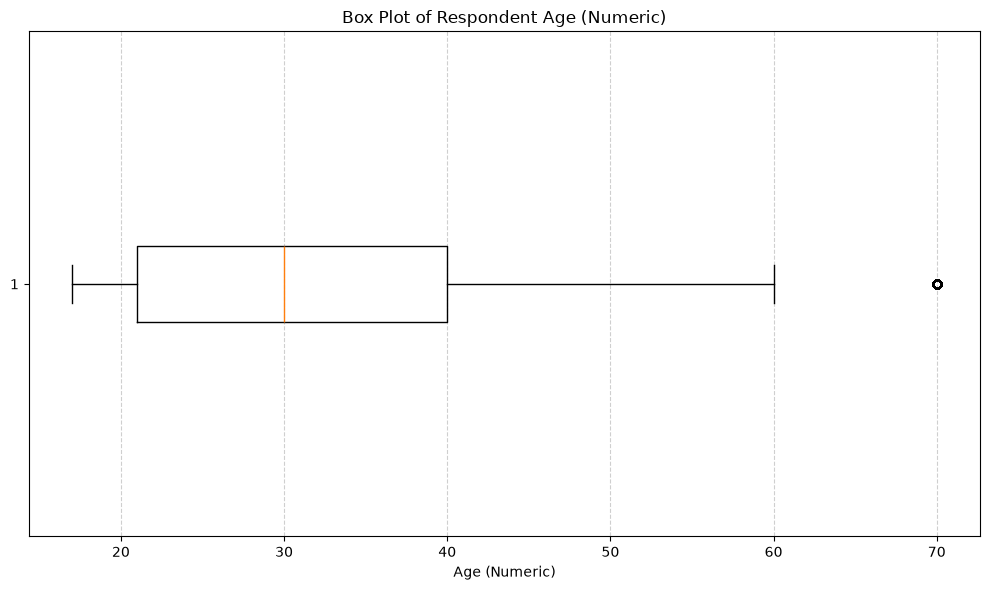

In [16]:
# your code goes here
def convert_age(age):
    if pd.isna(age):
        return None
    age = str(age)

    if "Under 18" in age: return 17
    if "18-24" in age: return 21
    if "25-34" in age: return 30
    if "35-44" in age: return 40
    if "45-54" in age: return 50
    if "55-64" in age: return 60
    if "65" in age: return 70
    return None

df_check['Age_numeric'] = df_check['Age'].apply(convert_age)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.boxplot(df_check['Age_numeric'].dropna(), vert=False)

plt.title("Box Plot of Respondent Age (Numeric)")
plt.xlabel("Age (Numeric)")
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


<Figure size 1200x600 with 0 Axes>

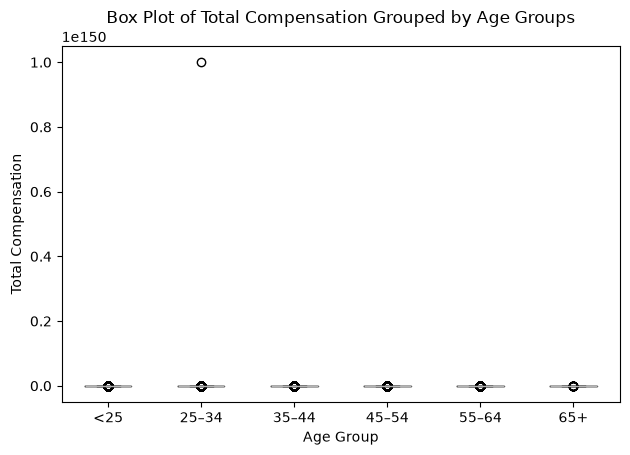

In [17]:
# your code goes here
df_check['CompTotal'] = (
    df_check['CompTotal']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ["<25", "25–34", "35–44", "45–54", "55–64", "65+"]

df_check['AgeGroup'] = pd.cut(df_check['Age_numeric'], bins=bins, labels=labels)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

df_check.boxplot(column='CompTotal', by='AgeGroup', grid=False)

plt.title("Box Plot of Total Compensation Grouped by Age Groups")
plt.suptitle("")  # removes the automatic pandas title
plt.xlabel("Age Group")
plt.ylabel("Total Compensation")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSatPoints_6`):**


Examine how compensation varies based on job satisfaction levels.


/tmp/ipykernel_300/2078922536.py:34: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data_groups, vert=True)


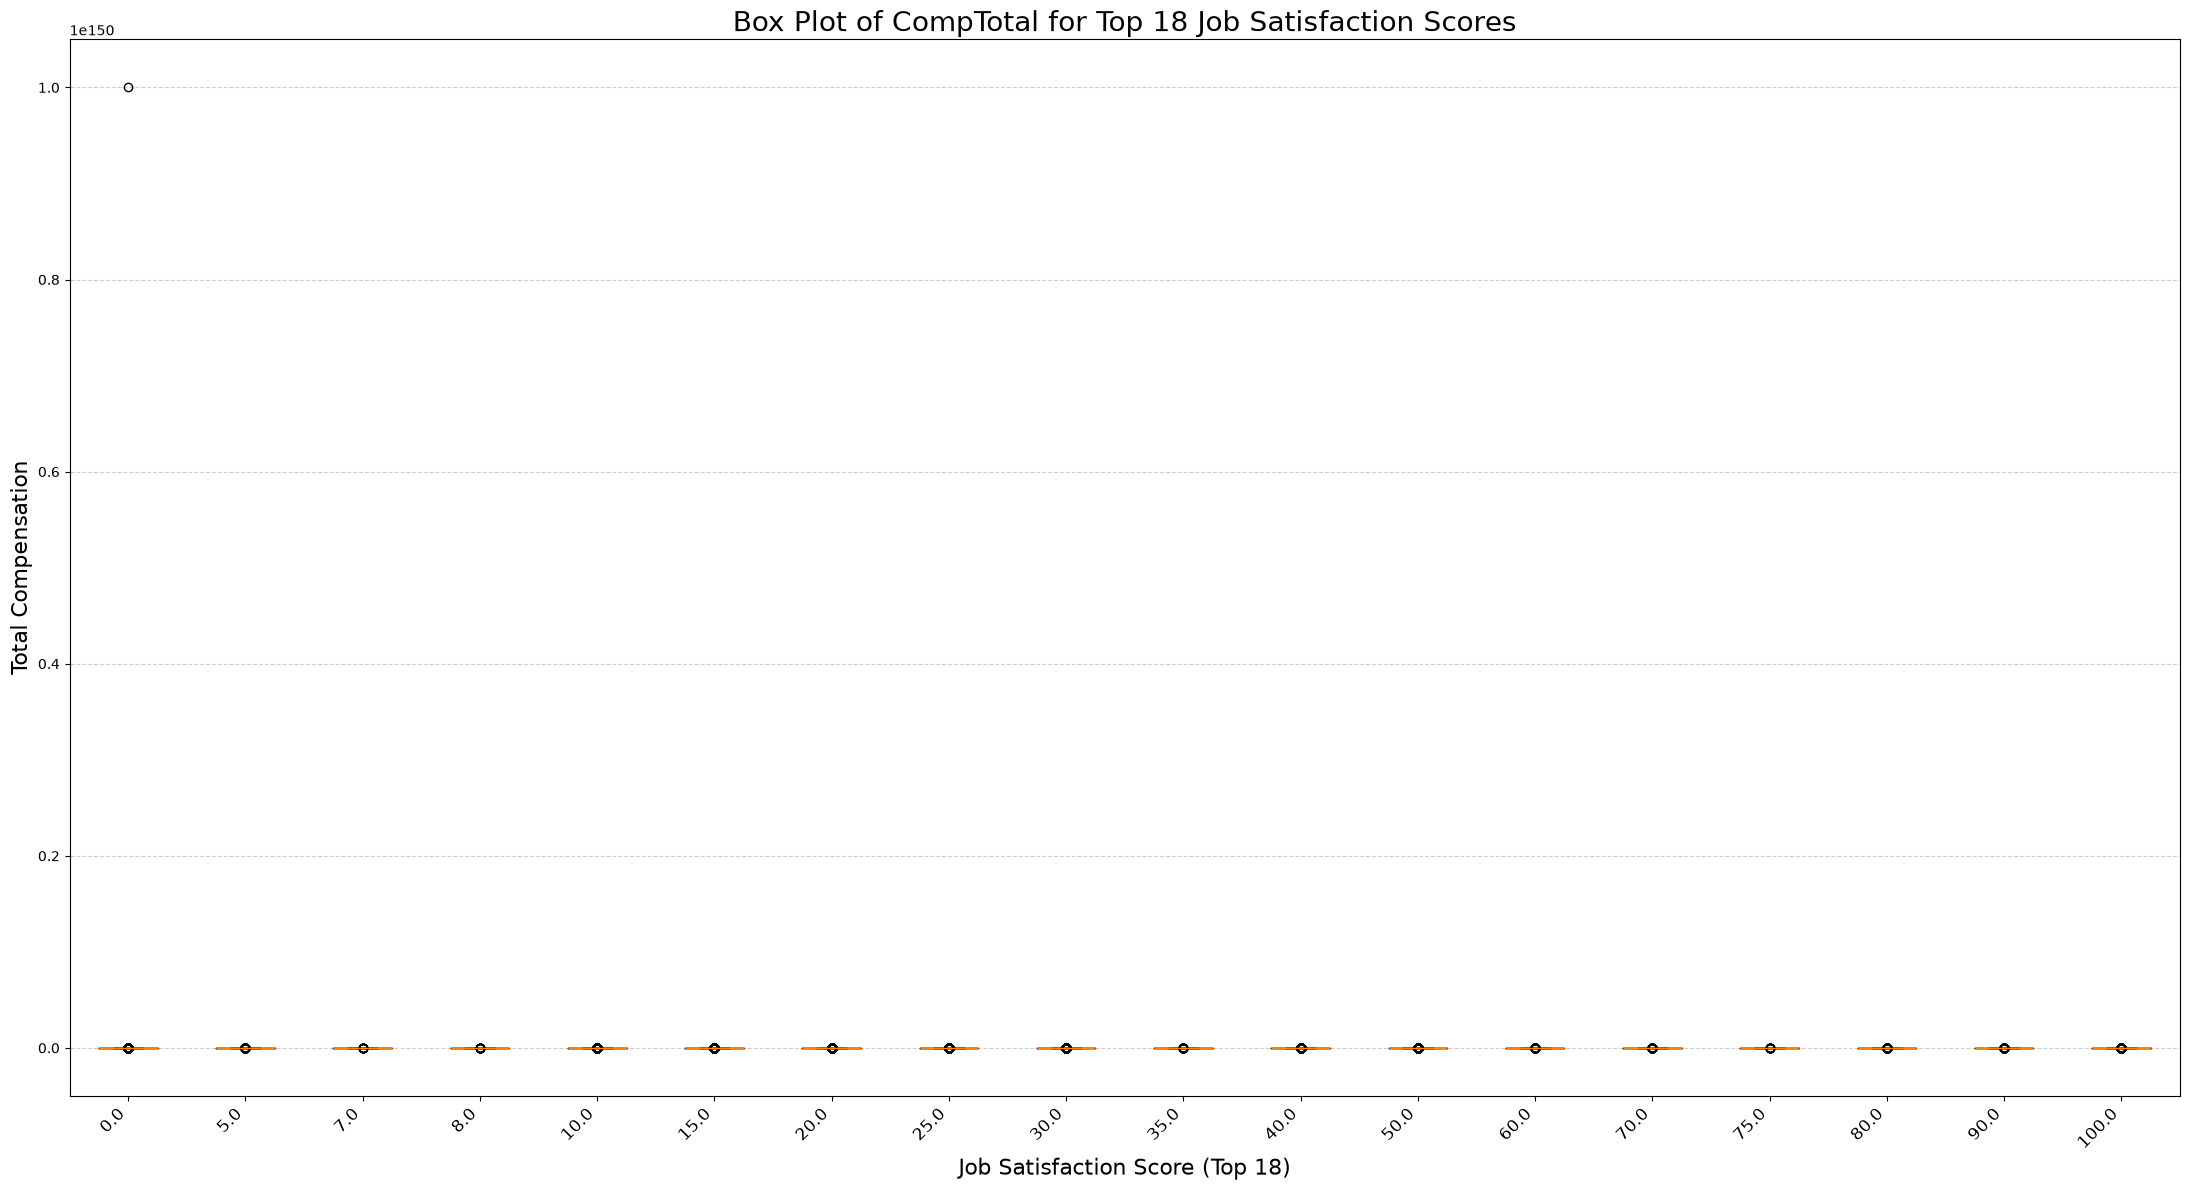

In [36]:
# your code goes here
df_check['CompTotal'] = (
    df_check['CompTotal']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')
df_check['JobSatPoints_6'] = pd.to_numeric(df_check['JobSatPoints_6'], errors='coerce')
top18_scores = (
    df_check['JobSatPoints_6']
    .value_counts()
    .head(18)
    .index
    .tolist()
)
df_top18 = df_check[df_check['JobSatPoints_6'].isin(top18_scores)]
import matplotlib.pyplot as plt

# Drop missing values
df_plot = df_top18[['CompTotal', 'JobSatPoints_6']].dropna()

# Sort the top 18 scores
sorted_scores = sorted(df_plot['JobSatPoints_6'].unique())

# Build data groups
data_groups = [
    df_plot[df_plot['JobSatPoints_6'] == score]['CompTotal']
    for score in sorted_scores
]

plt.figure(figsize=(22,12))  # Large plot for readability

plt.boxplot(data_groups, vert=True)

# Add labels manually (Matplotlib version-safe)
plt.xticks(
    ticks=range(1, len(sorted_scores)+1),
    labels=sorted_scores,
    rotation=45,
    ha='right',
    fontsize=12
)

plt.title("Box Plot of CompTotal for Top 18 Job Satisfaction Scores", fontsize=20)
plt.xlabel("Job Satisfaction Score (Top 18)", fontsize=16)
plt.ylabel("Total Compensation", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


### Task 3: Visualizing the Composition of Data


**1. Box Plot of `ConvertedCompYearly` for the Top 5 Developer Types:**


Analyze compensation across the top 5 developer roles.


/tmp/ipykernel_300/497817676.py:39: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data_groups, vert=True)


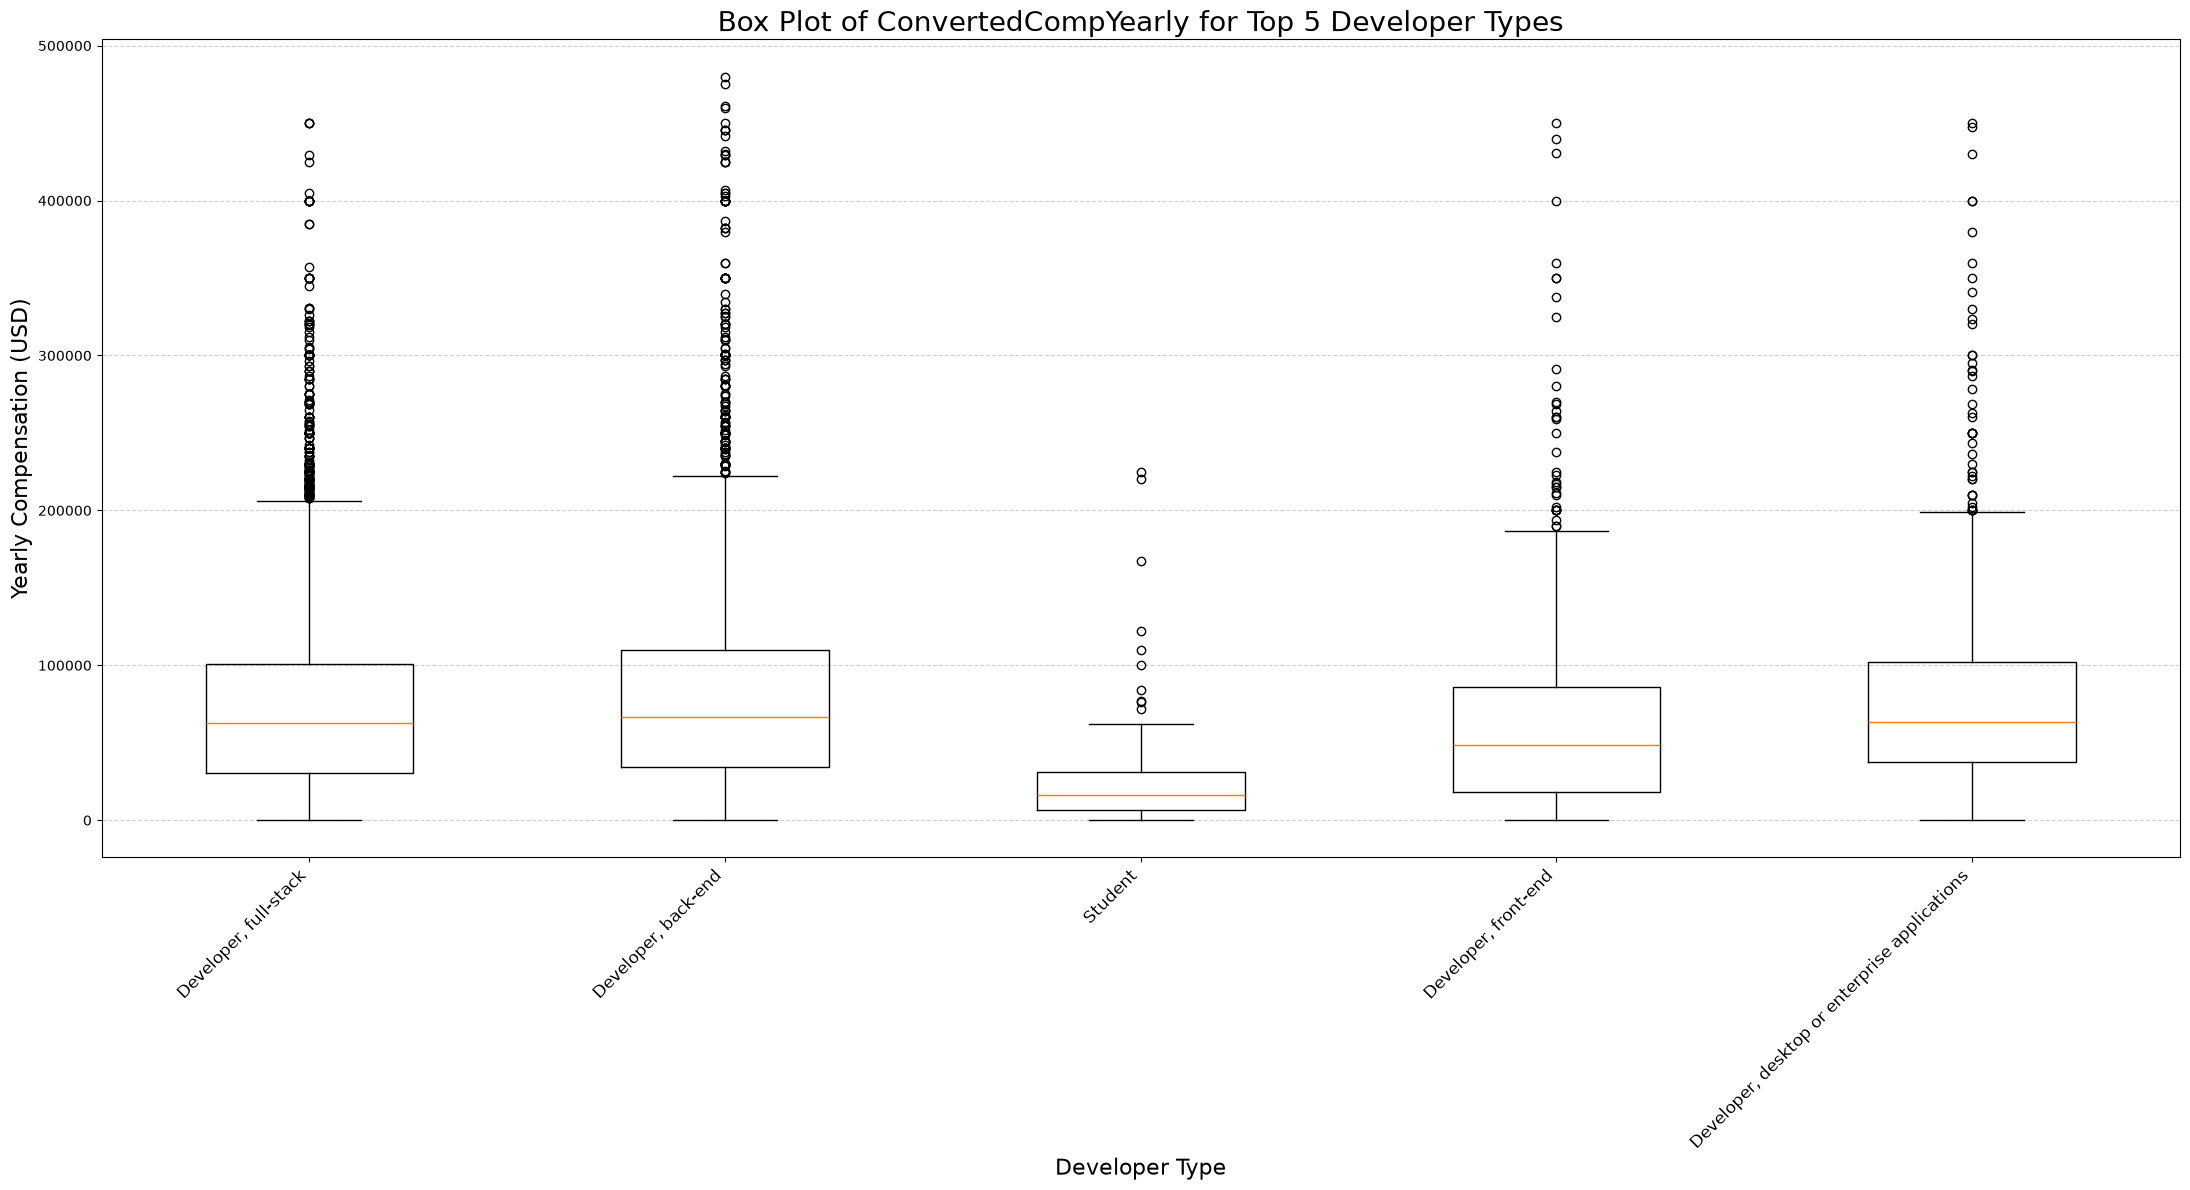

In [35]:
# Split multi-select DevType values
dev_expanded = df_check['DevType'].dropna().str.split(';')

from collections import Counter
dev_counts = Counter([item.strip() for sublist in dev_expanded for item in sublist])

top5_devtypes = [dev for dev, count in dev_counts.most_common(5)]
top5_devtypes
def extract_primary_devtype(x):
    if pd.isna(x):
        return None
    for dev in top5_devtypes:
        if dev in x:
            return dev
    return None

df_check['PrimaryDevType'] = df_check['DevType'].apply(extract_primary_devtype)
df_check['ConvertedCompYearly'] = (
    df_check['ConvertedCompYearly']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_check['ConvertedCompYearly'] = pd.to_numeric(df_check['ConvertedCompYearly'], errors='coerce')

df_clean = df_check[df_check['ConvertedCompYearly'] < 500000]
import matplotlib.pyplot as plt

df_plot = df_clean[df_clean['PrimaryDevType'].isin(top5_devtypes)]

# Build data groups
data_groups = [
    df_plot[df_plot['PrimaryDevType'] == dev]['ConvertedCompYearly'].dropna()
    for dev in top5_devtypes
]

plt.figure(figsize=(22,12))  # Large plot

plt.boxplot(data_groups, vert=True)

# Add labels manually (Matplotlib version-safe)
plt.xticks(
    ticks=range(1, len(top5_devtypes)+1),
    labels=top5_devtypes,
    rotation=45,
    ha='right',
    fontsize=12
)

plt.title("Box Plot of ConvertedCompYearly for Top 5 Developer Types", fontsize=20)
plt.xlabel("Developer Type", fontsize=16)
plt.ylabel("Yearly Compensation (USD)", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



**2. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


<Figure size 1400x700 with 0 Axes>

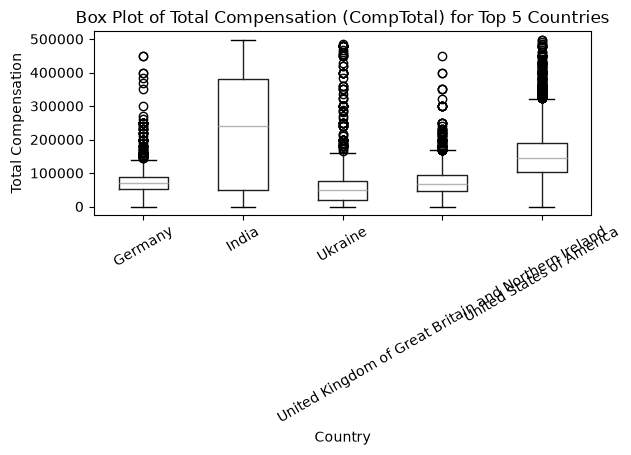

In [37]:
# your code goes here
df_check['CompTotal'] = (
    df_check['CompTotal']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')
#identify 5 top countries
top5_countries = df_check['Country'].value_counts().head(5).index.tolist()
top5_countries
df_top5 = df_check[df_check['Country'].isin(top5_countries)]
#remove extreme outliers
df_top5 = df_top5[df_top5['CompTotal'] < 500000]   # cap at $500k
import matplotlib.pyplot as plt

plt.figure(figsize=(14,7))

df_top5.boxplot(column='CompTotal', by='Country', grid=False)

plt.title("Box Plot of Total Compensation (CompTotal) for Top 5 Countries")
plt.suptitle("")  # remove pandas default title
plt.xlabel("Country")
plt.ylabel("Total Compensation")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


### Task 4: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


<Figure size 1400x700 with 0 Axes>

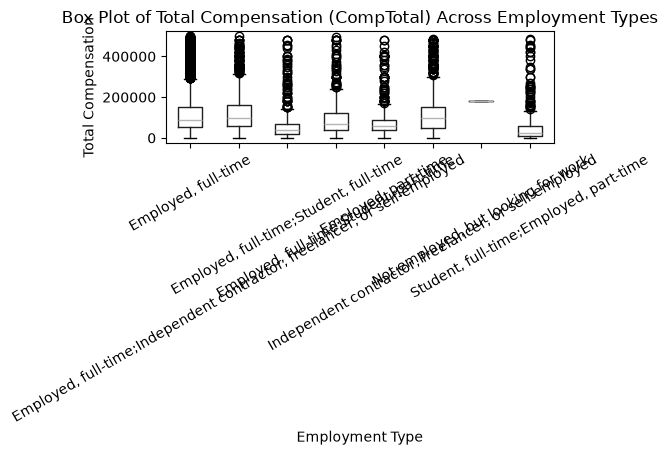

In [31]:
# your code goes here
df_check['CompTotal'] = (
    df_check['CompTotal']
    .astype(str)
    .str.replace(',', '', regex=False)
)

df_check['CompTotal'] = pd.to_numeric(df_check['CompTotal'], errors='coerce')
#identify top 5 emplyment types
top_employment = df_check['Employment'].value_counts().head(10).index.tolist()
top_employment
df_emp = df_check[df_check['Employment'].isin(top_employment)]
#remove extreme outliers
df_emp = df_emp[df_emp['CompTotal'] < 500000]   # cap at $500k
#box plot of comptotal grouped by employment type
import matplotlib.pyplot as plt


plt.figure(figsize=(14,7))

df_emp.boxplot(column='CompTotal', by='Employment', grid=False)

plt.title("Box Plot of Total Compensation (CompTotal) Across Employment Types")
plt.suptitle("")  # remove pandas default title
plt.xlabel("Employment Type")
plt.ylabel("Total Compensation")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()



**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSatPoints_6`):**


Examine the distribution of professional coding years by job satisfaction levels.


/tmp/ipykernel_300/2278880280.py:31: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data_groups, vert=True)


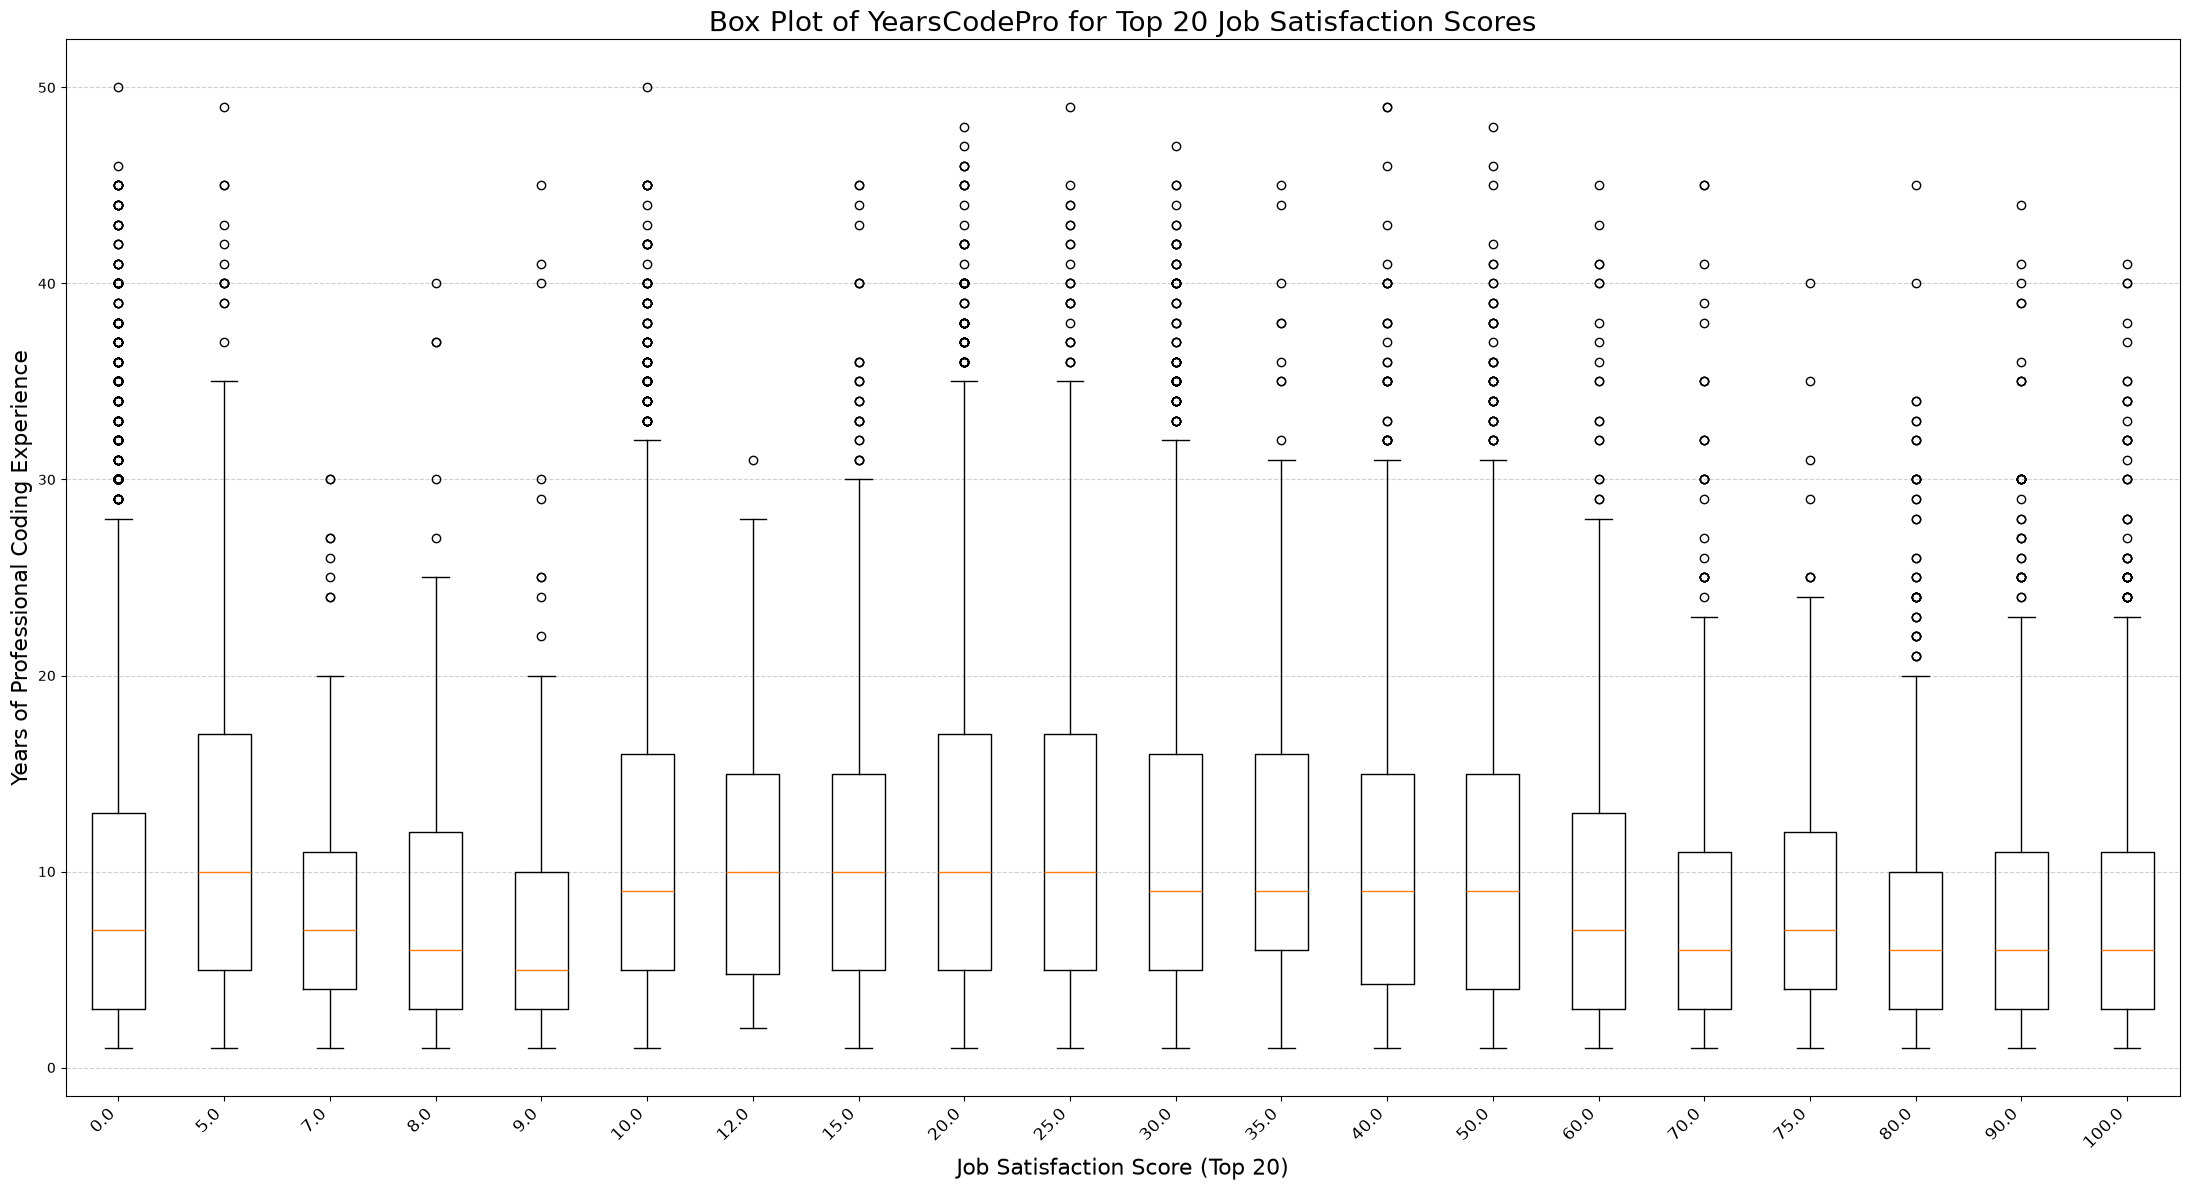

In [34]:
# your code goes here
top20_scores = (
    df_check['JobSatPoints_6']
    .value_counts()
    .head(20)
    .index
    .tolist()
)
df_top20 = df_check[df_check['JobSatPoints_6'].isin(top20_scores)]
import matplotlib.pyplot as plt

# Ensure numeric
df_top20['YearsCodePro'] = pd.to_numeric(df_top20['YearsCodePro'], errors='coerce')
df_top20['JobSatPoints_6'] = pd.to_numeric(df_top20['JobSatPoints_6'], errors='coerce')

# Drop missing
df_plot = df_top20[['YearsCodePro', 'JobSatPoints_6']].dropna()

# Sort the top 20 scores
sorted_scores = sorted(df_plot['JobSatPoints_6'].unique())

# Build data groups
data_groups = [
    df_plot[df_plot['JobSatPoints_6'] == score]['YearsCodePro']
    for score in sorted_scores
]

# Plot
plt.figure(figsize=(22,12))   # BIG plot for readability

plt.boxplot(data_groups, vert=True)

# Add labels manually
plt.xticks(
    ticks=range(1, len(sorted_scores)+1),
    labels=sorted_scores,
    rotation=45,
    ha='right',
    fontsize=12
)

plt.title("Box Plot of YearsCodePro for Top 20 Job Satisfaction Scores", fontsize=20)
plt.xlabel("Job Satisfaction Score (Top 20)", fontsize=16)
plt.ylabel("Years of Professional Coding Experience", fontsize=16)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()



### Final Step: Close the Database Connection


After completing the lab, close the connection to the SQLite database:


In [39]:
conn.close()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
